# Hybrid Strategy v2 — With Improvements 2 & 4

**Standalone notebook.** Requires only `data_for_experiments.csv`.

Builds on `hybrid_strategy.ipynb` with two proven improvements applied:
- **Improvement 2:** Stablecoins removed before label assignment (+10.16% spread, +73% win rate)
- **Improvement 4:** Walk-forward validation — model retrained every quarter

| Strategy | Long | Short | Description |
|---|---|---|---|
| Baseline v2 | Model A (top-30) | Model A (top-30) | Same structure as before, clean universe + walk-forward |
| H1 v2 | Model A (top-30) | Model B (technical) | Best-leg hybrid on clean universe |
| H2 v2 | Model A (skip bear weeks) | Model B (always) | Regime-gated on clean universe |
| H3 v2 | Ensemble probability | Ensemble probability | Combined signal on clean universe |

All results compared against the **original baseline** (with stablecoins, static split, 244x).

In [ ]:
from __future__ import annotations
from pathlib import Path
import warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier
warnings.filterwarnings('ignore')
BASE_DIR = Path.cwd().parent

IN_FILE = BASE_DIR / 'Data/data_for_experiments.csv'
OUT_DIR = BASE_DIR / 'Figures'

TRAIN_CUTOFF = '2024-01'
FORWARD_DAYS = 7
MIN_COINS    = 20
TOP_N        = 30

LABEL_ORDER = ['Strong Avoid', 'Avoid', 'Neutral', 'Buy', 'Strong Buy']
LABEL_MAP   = {'Strong Avoid': 0, 'Avoid': 1, 'Neutral': 2, 'Buy': 3, 'Strong Buy': 4}
BINS        = [0, 0.10, 0.30, 0.70, 0.90, 1.001]
LONG_LABEL  = 'Strong Buy'
SHORT_LABEL = 'Strong Avoid'
BTC_COLOR   = '#F7931A'
ETH_COLOR   = '#627EEA'

ORIG_BASELINE_CUM = 243.75
ORIG_H1_CUM       = 427.28

TECHNICAL_FEATURES = [
    'return_1d', 'return_7d', 'return_30d', 'volatility_30d',
    'rsi_14', 'macd_hist', 'bb_pct', 'bb_width', 'atr_pct', 'atr_14',
    'obv_divergence', 'obv', 'stoch_k', 'stoch_d',
    'adx', 'plus_di', 'minus_di', 'ema_50_vs_200',
    'price_vs_ema50', 'price_vs_ema200',
    'volume_vs_30d_avg', 'volume', 'drawdown_from_90d_peak',
    'price_vs_ath', 'price_vs_atl', 'range_position_30d',
]

LEAKY_COLS = {
    'label', 'forward_return_7d', 'forward_sharpe_7d', 'forward_sharpe_rank',
    'return_1d_rank', 'return_1d_zscore', 'return_7d_rank', 'return_7d_zscore',
    'return_30d_rank', 'return_30d_zscore', 'volatility_30d_rank', 'volatility_30d_zscore',
    'rsi_14_rank', 'rsi_14_zscore', 'macd_hist_rank', 'macd_hist_zscore',
    'bb_pct_rank', 'bb_pct_zscore', 'atr_pct_rank', 'atr_pct_zscore',
    'obv_divergence_rank', 'obv_divergence_zscore', 'stoch_k_rank', 'stoch_k_zscore',
    'adx_rank', 'adx_zscore', 'volume_vs_30d_avg_rank', 'volume_vs_30d_avg_zscore',
    'drawdown_from_90d_peak_rank', 'drawdown_from_90d_peak_zscore',
    'price_vs_ath_rank', 'price_vs_ath_zscore', 'range_position_30d_rank',
    'range_position_30d_zscore', 'consecutive_up_days_rank', 'consecutive_up_days_zscore',
    'consecutive_down_days_rank', 'consecutive_down_days_zscore',
    'coin_age_days_rank', 'coin_age_days_zscore',
    'momentum_score', 'mean_reversion_score', 'trend_score',
    'asset_id', 'year_week', 'date', 'timestamp', 'exchange',
    'pair_symbol', 'source', 'open', 'high', 'low', 'close',
    'granularity', 'is_active',
}

CS_FEATURES = [
    'return_1d', 'return_7d', 'return_30d', 'volatility_30d',
    'rsi_14', 'macd_hist', 'bb_pct', 'atr_pct', 'obv_divergence',
    'stoch_k', 'adx', 'volume_vs_30d_avg', 'drawdown_from_90d_peak',
    'price_vs_ath', 'range_position_30d', 'consecutive_up_days',
    'consecutive_down_days', 'coin_age_days', 'galaxy_score', 'alt_rank',
    'market_cap_usd', 'coin_mcap_share_recalc', 'oi_usd', 'funding_rate',
    'taker_buy_ratio',
]

XGB_PARAMS = dict(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', verbosity=0,
    random_state=42, n_jobs=-1
)

def prep(d, cols):
    available = [c for c in cols if c in d.columns]
    return d[available].fillna(0).replace([np.inf, -np.inf], 0).clip(-1e9, 1e9)

def cumret(s):
    return (1 + pd.Series(s).fillna(0)).cumprod()

def expand_group(base_names, available):
    expanded = []
    for f in base_names:
        for v in [f, f+'_rank', f+'_zscore']:
            if v in available:
                expanded.append(v)
    return list(dict.fromkeys(expanded))

print('Config loaded.')

Config loaded.


## 1. Load data — with stablecoin removal (Improvement 2)

In [ ]:
df = pd.read_csv(IN_FILE, low_memory=False)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['asset_id', 'date']).reset_index(drop=True)
df['year_week'] = df['date'].dt.strftime('%G-W%V')
print(f'Loaded: {df.shape[0]:,} rows | {df["asset_id"].nunique()} coins')

if 'is_stable' in df.columns:
    stable_ids = set(df[df['is_stable'] == 1]['asset_id'].unique())
else:
    coin_vol   = df.groupby('asset_id')['return_1d'].std()
    stable_ids = set(coin_vol[coin_vol < 0.002].index)
print(f'Removing {len(stable_ids)} stablecoins: {sorted(stable_ids)}')
df = df[~df['asset_id'].isin(stable_ids)].copy()
print(f'After removal: {df["asset_id"].nunique()} coins')

def compute_forward_sharpe_7d(group):
    closes, results = group['close'].values, []
    for i in range(len(closes)):
        end = i + FORWARD_DAYS
        if end >= len(closes):
            results.append(np.nan); continue
        window     = closes[i:end]
        daily_rets = np.diff(window) / window[:-1]
        fwd_ret    = (window[-1] - window[0]) / window[0]
        vol        = daily_rets.std() * np.sqrt(365)
        results.append((fwd_ret / vol) if vol > 1e-8 else 0.0)
    return pd.Series(results, index=group.index)

print('Computing forward Sharpe...')
df['forward_sharpe_7d'] = df.groupby('asset_id', group_keys=False).apply(compute_forward_sharpe_7d)
df['forward_return_7d'] = df.groupby('asset_id')['close'].transform(
    lambda x: x.shift(-FORWARD_DAYS) / x - 1)

weekly = (
    df.dropna(subset=['forward_sharpe_7d'])
    .sort_values('date')
    .groupby(['asset_id', 'year_week']).last().reset_index()
)

def assign_labels(group):
    if len(group) < MIN_COINS:
        return group.assign(label=np.nan, forward_sharpe_rank=np.nan)
    q = group['forward_sharpe_7d'].rank(pct=True)
    group = group.copy()
    group['forward_sharpe_rank'] = q
    group['label'] = pd.cut(q, bins=BINS, labels=LABEL_ORDER, include_lowest=True)
    return group

weekly = (
    weekly.groupby('year_week', group_keys=False).apply(assign_labels)
    .dropna(subset=['label']).reset_index(drop=True)
)
if 'year_week' not in weekly.columns:
    weekly['year_week'] = pd.to_datetime(weekly['date']).dt.strftime('%G-W%V')
print(f'Weekly snapshots: {len(weekly):,} rows, {weekly["year_week"].nunique()} weeks')

# ── Cross-sectional features ──────────────────────────────────────────────────
cs_cols = [c for c in CS_FEATURES if c in weekly.columns]
for col in cs_cols:
    weekly[f'{col}_rank']   = weekly.groupby('year_week')[col].transform(lambda x: x.rank(pct=True))
    weekly[f'{col}_zscore'] = weekly.groupby('year_week')[col].transform(
        lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1))

cutoff_date = pd.Timestamp(TRAIN_CUTOFF + '-01')
train_df = weekly[pd.to_datetime(weekly['date']) <  cutoff_date].copy()
test_df  = weekly[pd.to_datetime(weekly['date']) >= cutoff_date].copy()
print(f'Train: {len(train_df):,} | Test: {len(test_df):,}')

all_features = [
    c for c in weekly.columns
    if c not in LEAKY_COLS
    and weekly[c].dtype in [np.float64, np.float32, np.int64, np.int32]
]
null_rates   = train_df[all_features].isnull().mean()
all_features = [f for f in all_features if null_rates[f] <= 0.30]
print(f'Candidate features: {len(all_features)}')

y_train = train_df['label'].map(LABEL_MAP)
y_test  = test_df['label'].map(LABEL_MAP)

test_start = pd.Timestamp(TRAIN_CUTOFF + '-01')
df_btc = pd.read_csv(IN_FILE, low_memory=False)
df_btc['date'] = pd.to_datetime(df_btc['date'])
btc_w = df_btc[df_btc['asset_id']=='bitcoin'].set_index('date')['close'].resample('W').last().pct_change().loc[test_start:]
eth_w = df_btc[df_btc['asset_id']=='ethereum'].set_index('date')['close'].resample('W').last().pct_change().loc[test_start:]
del df_btc

btc_weekly_ret = df[df['asset_id'].isin(['bitcoin']) == False].iloc[0:0]['close'].copy()  # empty
btc_weekly_ret = (
    df[df['asset_id'] == 'bitcoin'].set_index('date')['close']
    .resample('W').last().pct_change()
)
week_to_btc = {}
for wk in weekly['year_week'].unique():
    last_date = pd.to_datetime(weekly[weekly['year_week'] == wk]['date'].max())
    idx = btc_weekly_ret.index.asof(last_date)
    week_to_btc[wk] = btc_weekly_ret.get(idx, np.nan)

def classify_regime(r):
    if pd.isna(r):  return 'Sideways'
    if r >  0.05:   return 'Bull'
    if r < -0.05:   return 'Bear'
    return 'Sideways'

test_df = test_df.copy()
test_df['regime']     = test_df['year_week'].map(week_to_btc).apply(classify_regime)
test_df['btc_ret_wk'] = test_df['year_week'].map(week_to_btc)
print('\nTest regime distribution (weeks):')
print(test_df.groupby('regime')['year_week'].nunique().rename('weeks'))

Loaded: 211,498 rows | 164 coins
Removing 11 stablecoins: ['bfusd', 'dai', 'falcon-finance-ff', 'first-digital-usd', 'frax', 'pax-gold', 'paypal-usd', 'ripple-usd', 'stable-2', 'true-usd', 'usd1-wlfi']
After removal: 153 coins
Computing forward Sharpe...
Weekly snapshots: 28,754 rows, 359 weeks
Train: 15,068 | Test: 13,686
Candidate features: 103

Test regime distribution (weeks):
regime
Bear        16
Bull        23
Sideways    73
Name: weeks, dtype: int64


## 2. Feature selection and train static models (Improvement 2 only)

These models use the clean universe but the original static train/test split.
Used for H1, H2, H3 strategies.

In [ ]:
print('RF pass-1 feature selection (no stablecoins)...')
rf_sel = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_leaf=5,
    max_features='sqrt', class_weight='balanced',
    oob_score=True, n_jobs=-1, random_state=42
)
rf_sel.fit(prep(train_df, all_features), y_train)
imp   = pd.Series(rf_sel.feature_importances_, index=all_features).sort_values(ascending=False)
top30 = imp.head(TOP_N).index.tolist()
print(f'  OOB: {rf_sel.oob_score_*100:.2f}%  |  top-30 selected')

tech_feats = expand_group(TECHNICAL_FEATURES, all_features)
print(f'  Technical features: {len(tech_feats)}')

print('\nTraining Model A: Full top-30 XGBoost...')
model_A = XGBClassifier(**XGB_PARAMS)
model_A.fit(prep(train_df, top30), y_train)
pred_A  = model_A.predict(prep(test_df, top30))
prob_A  = model_A.predict_proba(prep(test_df, top30))
acc_A   = accuracy_score(y_test, pred_A)
print(f'  Accuracy: {acc_A*100:.2f}%')

print('Training Model B: Technical-only XGBoost...')
model_B = XGBClassifier(**XGB_PARAMS)
model_B.fit(prep(train_df, tech_feats), y_train)
pred_B  = model_B.predict(prep(test_df, tech_feats))
prob_B  = model_B.predict_proba(prep(test_df, tech_feats))
acc_B   = accuracy_score(y_test, pred_B)
print(f'  Accuracy: {acc_B*100:.2f}%')

labels_A = pd.Series([LABEL_ORDER[p] for p in pred_A], index=test_df.index)
labels_B = pd.Series([LABEL_ORDER[p] for p in pred_B], index=test_df.index)
print('\nBoth models trained.')

RF pass-1 feature selection (no stablecoins)...
  OOB: 28.38%  |  top-30 selected
  Technical features: 26

Training Model A: Full top-30 XGBoost...
  Accuracy: 38.02%
Training Model B: Technical-only XGBoost...
  Accuracy: 38.48%

Both models trained.


## 3. Walk-forward models (Improvement 4)

Quarterly retraining on the clean (no-stablecoin) universe.
Both Model A and Model B retrained each quarter.

In [ ]:
print('Walk-forward: training Model A and Model B per quarter...')
weekly_wf = weekly.copy()
weekly_wf['date'] = pd.to_datetime(weekly_wf['date'])


wf_parts_A = []
wf_parts_B = []

for i, q_start in enumerate(pd.date_range('2024-01-01', '2026-03-01', freq='QS')):
    q_end  = q_start + pd.DateOffset(months=3)
    tr_q   = weekly_wf[weekly_wf['date'] <  q_start].copy()
    te_q   = weekly_wf[(weekly_wf['date'] >= q_start) & (weekly_wf['date'] < q_end)].copy()
    if len(tr_q) < 500 or len(te_q) < 50: continue

    y_tr_q = tr_q['label'].map(LABEL_MAP).dropna()
    y_te_q = te_q['label'].map(LABEL_MAP).dropna()
    tr_q, te_q = tr_q.loc[y_tr_q.index], te_q.loc[y_te_q.index]

    feats_q = [
        c for c in weekly_wf.columns
        if c not in LEAKY_COLS
        and weekly_wf[c].dtype in [np.float64, np.float32, np.int64, np.int32]
        and tr_q[c].isnull().mean() <= 0.30
    ]

    rf_q = RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=5,
        max_features='sqrt', class_weight='balanced',
        oob_score=True, n_jobs=-1, random_state=42
    )
    rf_q.fit(prep(tr_q, feats_q), y_tr_q)
    imp_q   = pd.Series(rf_q.feature_importances_, index=feats_q).sort_values(ascending=False)
    top30_q = imp_q.head(TOP_N).index.tolist()
    tech_q  = expand_group(TECHNICAL_FEATURES, feats_q)

    clf_Aq = XGBClassifier(**XGB_PARAMS)
    clf_Aq.fit(prep(tr_q, top30_q), y_tr_q)
    pred_Aq = clf_Aq.predict(prep(te_q, top30_q))
    prob_Aq = clf_Aq.predict_proba(prep(te_q, top30_q))
    acc_Aq  = accuracy_score(y_te_q, pred_Aq)

    clf_Bq = XGBClassifier(**XGB_PARAMS)
    clf_Bq.fit(prep(tr_q, tech_q), y_tr_q)
    pred_Bq = clf_Bq.predict(prep(te_q, tech_q))
    prob_Bq = clf_Bq.predict_proba(prep(te_q, tech_q))

    print(f'  Q{i+1} ({q_start.date()}→{q_end.date()}): '
          f'A acc={acc_Aq*100:.1f}%  test={len(te_q):,}')

    te_slice = te_q.copy()
    te_slice['_pred_A'] = pred_Aq
    te_slice['_pred_B'] = pred_Bq
    te_slice['_prob_A_SB'] = prob_Aq[:, 4]
    te_slice['_prob_A_SA'] = prob_Aq[:, 0]
    te_slice['_prob_B_SB'] = prob_Bq[:, 4]
    te_slice['_prob_B_SA'] = prob_Bq[:, 0]
    wf_parts_A.append(te_slice)

test_wf = pd.concat(wf_parts_A).reset_index(drop=True)
test_wf['regime'] = test_wf['year_week'].map(week_to_btc).apply(classify_regime)

labels_A_wf = pd.Series([LABEL_ORDER[p] for p in test_wf['_pred_A'].values], index=test_wf.index)
labels_B_wf = pd.Series([LABEL_ORDER[p] for p in test_wf['_pred_B'].values], index=test_wf.index)

print(f'\nWalk-forward test set: {len(test_wf):,} rows, {test_wf["year_week"].nunique()} weeks')

Walk-forward: training Model A and Model B per quarter...
  Q1 (2024-01-01→2024-04-01): A acc=37.0%  test=1,321
  Q2 (2024-04-01→2024-07-01): A acc=37.3%  test=1,389
  Q3 (2024-07-01→2024-10-01): A acc=39.1%  test=1,414
  Q4 (2024-10-01→2025-01-01): A acc=37.4%  test=1,481
  Q5 (2025-01-01→2025-04-01): A acc=40.3%  test=1,617
  Q6 (2025-04-01→2025-07-01): A acc=39.3%  test=1,661
  Q7 (2025-07-01→2025-10-01): A acc=39.7%  test=1,753
  Q8 (2025-10-01→2026-01-01): A acc=38.6%  test=1,860
  Q9 (2026-01-01→2026-04-01): A acc=38.4%  test=1,190

Walk-forward test set: 13,686 rows, 112 weeks


## 4. Strategy engine

In [5]:
def run_strategy(df_te, long_labels, short_labels, name):
    rows = []
    for wk in sorted(df_te['year_week'].unique()):
        m = df_te[df_te['year_week'] == wk]

        if long_labels is not None:
            l = long_labels[m.index]
            lc = m[l == LONG_LABEL]
            lr = lc['forward_return_7d'].median() if len(lc) else np.nan
            ln = len(lc)
        else:
            lr, ln = np.nan, 0

        if short_labels is not None:
            s = short_labels[m.index]
            sc = m[s == SHORT_LABEL]
            sr = sc['forward_return_7d'].median() if len(sc) else np.nan
            sn = len(sc)
        else:
            sr, sn = np.nan, 0

        net = (lr - sr) if (pd.notna(lr) and pd.notna(sr)) else \
              (lr if pd.notna(lr) else (-sr if pd.notna(sr) else np.nan))

        rows.append({'week': wk, 'long_ret': lr, 'short_ret': sr,
                     'net': net, 'long_n': ln, 'short_n': sn})

    pnl   = pd.DataFrame(rows).set_index('week')
    valid = pnl['net'].dropna()
    cum   = cumret(pnl['net']).values[-1]
    print(f'{name}:')
    print(f'  Avg net P&L : {valid.mean()*100:+.2f}%')
    print(f'  Win rate    : {(valid>0).mean()*100:.0f}%')
    print(f'  Ann. spread : {valid.mean()*52*100:+.1f}%')
    print(f'  Cumulative  : {cum:.2f}x')
    return pnl

print('Strategy engine ready.')

Strategy engine ready.


## 5. Run all strategies

In [7]:
print('=' * 60)
print('STATIC SPLIT — No stablecoins (Improvement 2 only)')
print('=' * 60)

print('\n=== BASELINE v2 (static) ===')
pnl_base_v2 = run_strategy(test_df, labels_A, labels_A, 'Baseline v2 (no stablecoins, static)')

print('\n=== H1 v2 (static) — Model A long + Model B short ===')
pnl_H1_v2 = run_strategy(test_df, labels_A, labels_B, 'H1 v2 (no stablecoins, static)')

print('\n=== H2 v2 (static) — Regime-gated ===')
rows_H2 = []
for wk in sorted(test_df['year_week'].unique()):
    m      = test_df[test_df['year_week'] == wk]
    regime = m['regime'].iloc[0]
    s      = labels_B[m.index]
    sc     = m[s == SHORT_LABEL]
    sr     = sc['forward_return_7d'].median() if len(sc) else np.nan
    if regime == 'Bear':
        lr, ln = np.nan, 0
    else:
        l  = labels_A[m.index]
        lc = m[l == LONG_LABEL]
        lr = lc['forward_return_7d'].median() if len(lc) else np.nan
        ln = len(lc)
    net = (lr - sr) if (pd.notna(lr) and pd.notna(sr)) else (-sr if pd.notna(sr) else np.nan)
    rows_H2.append({'week': wk, 'long_ret': lr, 'short_ret': sr,
                    'net': net, 'long_n': ln, 'short_n': len(sc), 'regime': regime})
pnl_H2_v2 = pd.DataFrame(rows_H2).set_index('week')
valid_H2   = pnl_H2_v2['net'].dropna()
print(f'H2 v2 (regime-gated):')
print(f'  Avg net P&L : {valid_H2.mean()*100:+.2f}%')
print(f'  Win rate    : {(valid_H2>0).mean()*100:.0f}%')
print(f'  Cumulative  : {cumret(pnl_H2_v2["net"]).values[-1]:.2f}x')

print('\n=== H3 v2 (static) — Ensemble ===')
test_df_h3 = test_df.copy()
test_df_h3['ens_SB'] = (prob_A[:, 4] + prob_B[:, 4]) / 2
test_df_h3['ens_SA'] = (prob_A[:, 0] + prob_B[:, 0]) / 2

def assign_ens_labels(group):
    g = group.copy()
    g['ens_label'] = 'Neutral'
    g.loc[g['ens_SB'] >= g['ens_SB'].quantile(0.90), 'ens_label'] = 'Strong Buy'
    g.loc[g['ens_SA'] >= g['ens_SA'].quantile(0.90), 'ens_label'] = 'Strong Avoid'
    return g

test_df_h3 = test_df_h3.groupby('year_week', group_keys=False).apply(assign_ens_labels).reset_index(drop=True)
if 'year_week' not in test_df_h3.columns:
    test_df_h3['year_week'] = pd.to_datetime(test_df_h3['date']).dt.strftime('%G-W%V')
labels_ens = test_df_h3['ens_label']
pnl_H3_v2  = run_strategy(test_df_h3, labels_ens, labels_ens, 'H3 v2 (ensemble, static)')

print('\n' + '=' * 60)
print('WALK-FORWARD — No stablecoins + quarterly retraining (Imp 2+4)')
print('=' * 60)

print('\n=== BASELINE v3 (walk-forward) ===')
pnl_base_wf = run_strategy(test_wf, labels_A_wf, labels_A_wf, 'Baseline v3 (walk-forward)')

print('\n=== H1 v3 (walk-forward) ===')
pnl_H1_wf = run_strategy(test_wf, labels_A_wf, labels_B_wf, 'H1 v3 (walk-forward)')

print('\n=== H2 v3 (walk-forward, regime-gated) ===')
rows_H2_wf = []
for wk in sorted(test_wf['year_week'].unique()):
    m      = test_wf[test_wf['year_week'] == wk]
    regime = m['regime'].iloc[0]
    s      = labels_B_wf[m.index]
    sc     = m[s == SHORT_LABEL]
    sr     = sc['forward_return_7d'].median() if len(sc) else np.nan
    if regime == 'Bear':
        lr, ln = np.nan, 0
    else:
        l  = labels_A_wf[m.index]
        lc = m[l == LONG_LABEL]
        lr = lc['forward_return_7d'].median() if len(lc) else np.nan
        ln = len(lc)
    net = (lr - sr) if (pd.notna(lr) and pd.notna(sr)) else (-sr if pd.notna(sr) else np.nan)
    rows_H2_wf.append({'week': wk, 'long_ret': lr, 'short_ret': sr,
                       'net': net, 'long_n': ln, 'short_n': len(sc), 'regime': regime})
pnl_H2_wf = pd.DataFrame(rows_H2_wf).set_index('week')
valid_wf   = pnl_H2_wf['net'].dropna()
print(f'H2 v3 (walk-forward, regime-gated):')
print(f'  Avg net P&L : {valid_wf.mean()*100:+.2f}%')
print(f'  Win rate    : {(valid_wf>0).mean()*100:.0f}%')
print(f'  Cumulative  : {cumret(pnl_H2_wf["net"]).values[-1]:.2f}x')

print('\n=== H3 v3 (walk-forward, ensemble) ===')
test_wf_h3 = test_wf.copy()
test_wf_h3['ens_SB'] = (test_wf['_prob_A_SB'] + test_wf['_prob_B_SB']) / 2
test_wf_h3['ens_SA'] = (test_wf['_prob_A_SA'] + test_wf['_prob_B_SA']) / 2
test_wf_h3 = test_wf_h3.groupby('year_week', group_keys=False).apply(assign_ens_labels).reset_index(drop=True)
if 'year_week' not in test_wf_h3.columns:
    test_wf_h3['year_week'] = pd.to_datetime(test_wf_h3['date']).dt.strftime('%G-W%V')
labels_ens_wf = test_wf_h3['ens_label']
pnl_H3_wf = run_strategy(test_wf_h3, labels_ens_wf, labels_ens_wf, 'H3 v3 (walk-forward, ensemble)')

STATIC SPLIT — No stablecoins (Improvement 2 only)

=== BASELINE v2 (static) ===
Baseline v2 (no stablecoins, static):
  Avg net P&L : +6.80%
  Win rate    : 67%
  Ann. spread : +353.6%
  Cumulative  : 151.44x

=== H1 v2 (static) — Model A long + Model B short ===
H1 v2 (no stablecoins, static):
  Avg net P&L : +6.89%
  Win rate    : 67%
  Ann. spread : +358.5%
  Cumulative  : 250.72x

=== H2 v2 (static) — Regime-gated ===
H2 v2 (regime-gated):
  Avg net P&L : +6.70%
  Win rate    : 66%
  Cumulative  : 75.59x

=== H3 v2 (static) — Ensemble ===
H3 v2 (ensemble, static):
  Avg net P&L : +2.07%
  Win rate    : 65%
  Ann. spread : +107.8%
  Cumulative  : 8.93x

WALK-FORWARD — No stablecoins + quarterly retraining (Imp 2+4)

=== BASELINE v3 (walk-forward) ===
Baseline v3 (walk-forward):
  Avg net P&L : +7.26%
  Win rate    : 64%
  Ann. spread : +377.3%
  Cumulative  : 375.59x

=== H1 v3 (walk-forward) ===
H1 v3 (walk-forward):
  Avg net P&L : +7.18%
  Win rate    : 64%
  Ann. spread : +373.

## 6. Per-regime breakdown

In [8]:
regime_map_static = test_df.groupby('year_week')['regime'].first()
regime_map_wf     = test_wf.groupby('year_week')['regime'].first()

strategies_all = [
    ('Original baseline (with stablecoins)', None, None, 243.75, 6.16, 71),
    ('Original H1 (with stablecoins)',       None, None, 427.28, 6.61, 70),
]

static_strats = [
    ('Baseline v2 (no stable, static)', pnl_base_v2, regime_map_static),
    ('H1 v2 (no stable, static)',       pnl_H1_v2,   regime_map_static),
    ('H2 v2 (regime-gated, static)',    pnl_H2_v2,   regime_map_static),
    ('H3 v2 (ensemble, static)',        pnl_H3_v2,   regime_map_static),
]

wf_strats = [
    ('Baseline v3 (walk-forward)',      pnl_base_wf, regime_map_wf),
    ('H1 v3 (walk-forward)',            pnl_H1_wf,   regime_map_wf),
    ('H2 v3 (walk-fwd, regime-gated)', pnl_H2_wf,   regime_map_wf),
    ('H3 v3 (walk-fwd, ensemble)',      pnl_H3_wf,   regime_map_wf),
]

print(f'{"Strategy":<42} {"Cum":>8} {"Avg%":>7} {"WR%":>5} {"Bull":>7} {"Bear":>7} {"Side":>7}')
print('-' * 90)

summary_rows = []
for name, pnl, rmap in static_strats + wf_strats:
    s    = pnl['net'].dropna()
    cum  = cumret(pnl['net']).values[-1]
    avg  = s.mean() * 100
    wr   = (s > 0).mean() * 100
    pnl['_regime'] = pnl.index.map(rmap)
    bull = pnl[pnl['_regime']=='Bull']['net'].dropna().mean() * 100
    bear = pnl[pnl['_regime']=='Bear']['net'].dropna().mean() * 100
    side = pnl[pnl['_regime']=='Sideways']['net'].dropna().mean() * 100
    print(f'{name:<42} {cum:>7.1f}x {avg:>+6.2f}% {wr:>4.0f}% {bull:>+6.2f}% {bear:>+6.2f}% {side:>+6.2f}%')
    summary_rows.append({'Strategy': name, 'Cum (x)': round(cum,1),
                         'Avg spread (%)': round(avg,2), 'Win rate (%)': round(wr,1),
                         'Bull (%)': round(bull,2), 'Bear (%)': round(bear,2),
                         'Sideways (%)': round(side,2)})

pd.DataFrame(summary_rows).to_csv(DYPLOM / 'hybrid_v2_summary.csv', index=False)
print('\nSaved -> hybrid_v2_summary.csv')

Strategy                                        Cum    Avg%   WR%    Bull    Bear    Side
------------------------------------------------------------------------------------------
Baseline v2 (no stable, static)              151.4x  +6.80%   67% +11.79% +15.15%  +3.49%
H1 v2 (no stable, static)                    250.7x  +6.89%   67%  +8.73% +15.42%  +4.20%
H2 v2 (regime-gated, static)                  75.6x  +6.70%   66% +11.13%  +6.36%  +5.23%
H3 v2 (ensemble, static)                       8.9x  +2.07%   65%  +2.44%  +2.38%  +1.89%
Baseline v3 (walk-forward)                   375.6x  +7.26%   64% +11.17%  +6.43%  +6.16%
H1 v3 (walk-forward)                         247.6x  +7.18%   64%  +9.65%  +6.56%  +6.50%
H2 v3 (walk-fwd, regime-gated)               109.0x  +7.83%   62% +11.80%  +3.68%  +7.56%
H3 v3 (walk-fwd, ensemble)                    13.2x  +2.44%   70%  +4.48%  +2.96%  +1.69%

Saved -> hybrid_v2_summary.csv


## 7. Figure 1 — Cumulative return: all strategies vs original

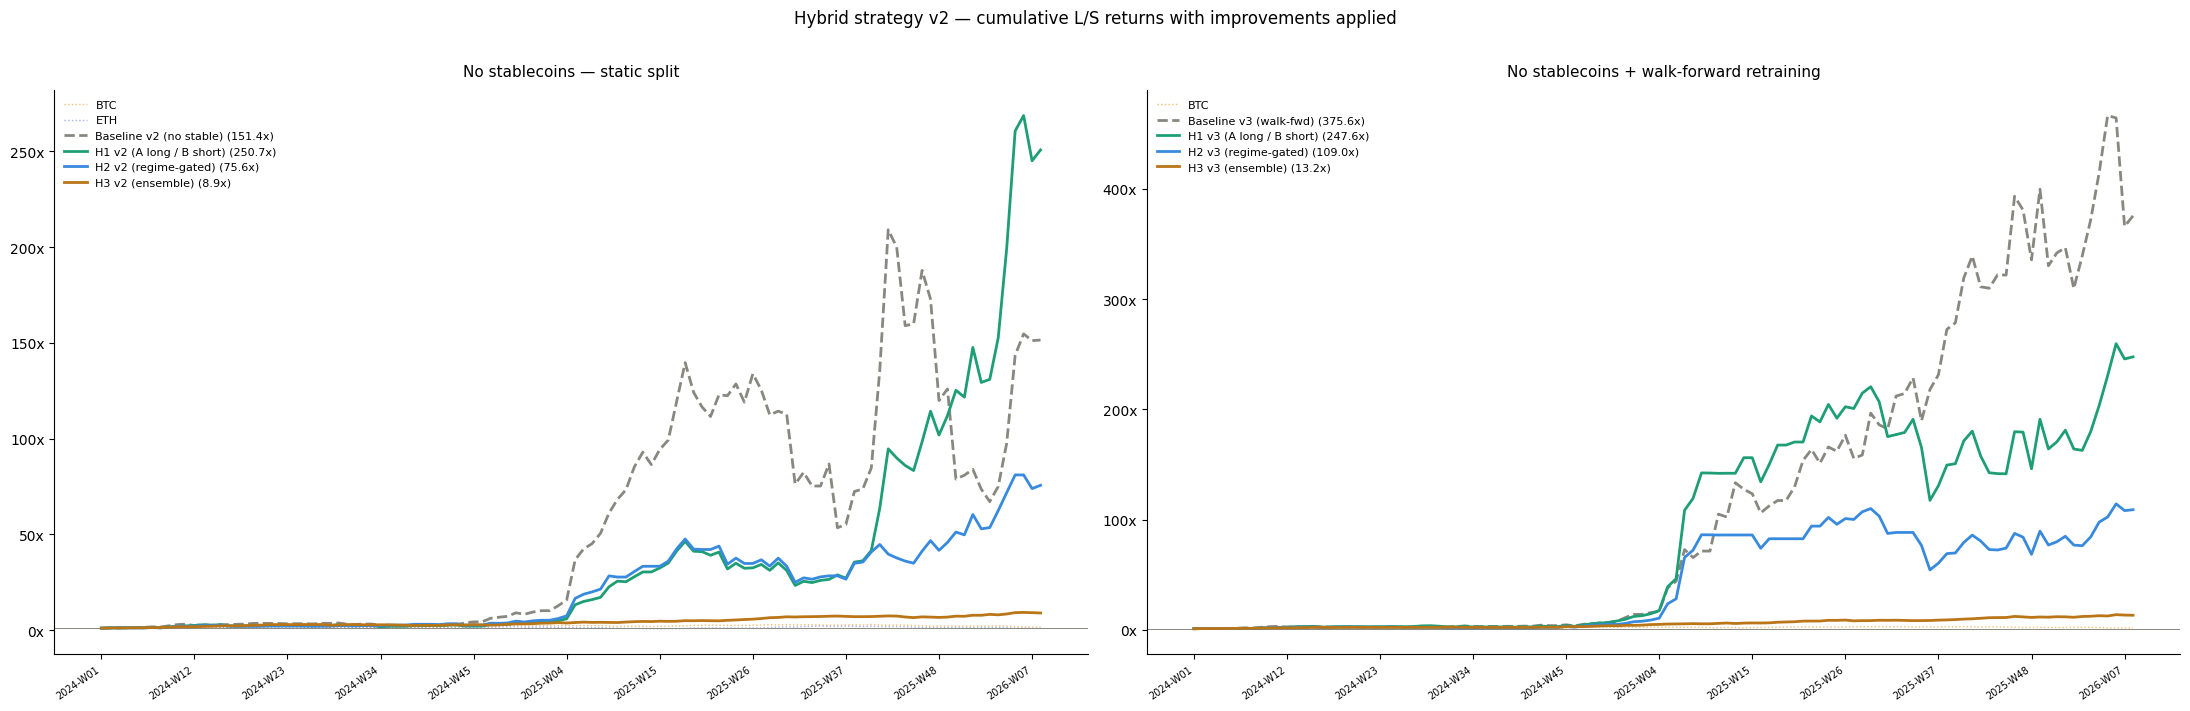

Saved -> hybrid_v2_cumulative.png


In [ ]:
wk_list_s  = sorted(test_df['year_week'].unique())
wk_list_wf = sorted(test_wf['year_week'].unique())
step = max(1, len(wk_list_s)//10)
n    = len(wk_list_s)
btc_cum = cumret(btc_w.reset_index(drop=True).iloc[:n])
eth_cum = cumret(eth_w.reset_index(drop=True).iloc[:n])

fig, axes = plt.subplots(1, 2, figsize=(22, 7))
fig.patch.set_facecolor('white')
ax = axes[0]
ax.plot(range(len(btc_cum)), btc_cum.values, color=BTC_COLOR, lw=1.0, ls=':', alpha=0.6, label='BTC')
ax.plot(range(len(eth_cum)), eth_cum.values, color=ETH_COLOR, lw=1.0, ls=':', alpha=0.6, label='ETH')
ax.axhline(1.0, color='#888780', lw=0.7)

plot_static = [
    (pnl_base_v2, '#888780', '--', 'Baseline v2 (no stable)'),
    (pnl_H1_v2,   '#1D9E75', '-',  'H1 v2 (A long / B short)'),
    (pnl_H2_v2,   '#378ADD', '-',  'H2 v2 (regime-gated)'),
    (pnl_H3_v2,   '#BA7517', '-',  'H3 v2 (ensemble)'),
]
for pnl, col, ls, lbl in plot_static:
    cum = cumret(pnl['net'])
    ax.plot(range(len(cum)), cum.values, color=col, lw=2.0, ls=ls,
            label=f'{lbl} ({cum.values[-1]:.1f}x)')

ax.set_xticks(range(0, n, step))
ax.set_xticklabels(wk_list_s[::step], rotation=35, ha='right', fontsize=7)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'{v:.0f}x'))
ax.set_title('No stablecoins — static split', fontsize=11, fontweight='500', pad=10)
ax.legend(fontsize=8, framealpha=0, loc='upper left')
ax.spines[['top','right']].set_visible(False); ax.set_facecolor('white')
ax = axes[1]
n_wf = len(wk_list_wf)
btc_cum_wf = cumret(btc_w.reset_index(drop=True).iloc[:n_wf])
ax.plot(range(len(btc_cum_wf)), btc_cum_wf.values, color=BTC_COLOR, lw=1.0, ls=':', alpha=0.6, label='BTC')
ax.axhline(1.0, color='#888780', lw=0.7)

plot_wf = [
    (pnl_base_wf, '#888780', '--', 'Baseline v3 (walk-fwd)'),
    (pnl_H1_wf,   '#1D9E75', '-',  'H1 v3 (A long / B short)'),
    (pnl_H2_wf,   '#378ADD', '-',  'H2 v3 (regime-gated)'),
    (pnl_H3_wf,   '#BA7517', '-',  'H3 v3 (ensemble)'),
]
step_wf = max(1, n_wf//10)
for pnl, col, ls, lbl in plot_wf:
    cum = cumret(pnl['net'])
    ax.plot(range(len(cum)), cum.values, color=col, lw=2.0, ls=ls,
            label=f'{lbl} ({cum.values[-1]:.1f}x)')

ax.set_xticks(range(0, n_wf, step_wf))
ax.set_xticklabels(wk_list_wf[::step_wf], rotation=35, ha='right', fontsize=7)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'{v:.0f}x'))
ax.set_title('No stablecoins + walk-forward retraining', fontsize=11, fontweight='500', pad=10)
ax.legend(fontsize=8, framealpha=0, loc='upper left')
ax.spines[['top','right']].set_visible(False); ax.set_facecolor('white')

plt.suptitle('Hybrid strategy v2 — cumulative L/S returns with improvements applied',
             fontsize=12, fontweight='500', y=1.01)
plt.tight_layout()
p = OUT_DIR / 'hybrid_v2_cumulative.png'
plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='white')
plt.show(); print(f'Saved -> {p.name}')

## 8. Figure 2 — Best version vs original baseline + BTC

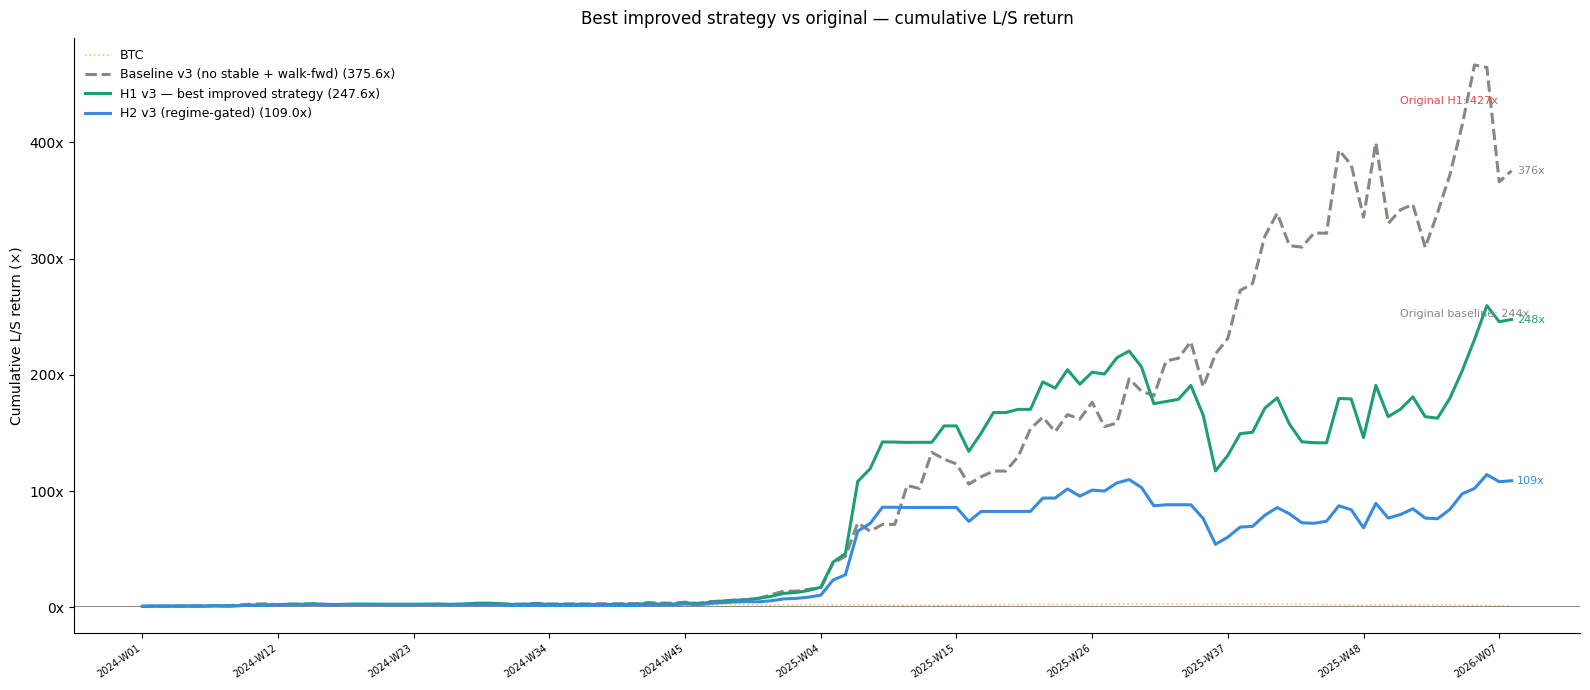

Saved -> hybrid_v2_best_vs_original.png

=== FINAL COMPARISON ===
Original baseline (with stablecoins, static):  244x
Original H1 (with stablecoins, static):         427x
Baseline v2 (no stable, static):               151.4x
H1 v2 (no stable, static):                     250.7x
Baseline v3 (no stable + walk-fwd):            375.6x
H1 v3 (no stable + walk-fwd):                  247.6x

=== All output files ===
  hybrid_v2_best_vs_original.png
  hybrid_v2_cumulative.png


In [ ]:
fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor('white')
ax.plot(range(len(btc_cum_wf)), btc_cum_wf.values,
        color=BTC_COLOR, lw=1.2, ls=':', alpha=0.6, label='BTC')
ax.axhline(1.0, color='#888780', lw=0.7)
orig_base_n = n
ax.annotate(f'Original baseline: {ORIG_BASELINE_CUM:.0f}x',
            xy=(orig_base_n-1, ORIG_BASELINE_CUM),
            fontsize=8, color='#888780',
            xytext=(-80, 5), textcoords='offset points')
ax.annotate(f'Original H1: {ORIG_H1_CUM:.0f}x',
            xy=(orig_base_n-1, ORIG_H1_CUM),
            fontsize=8, color='#E24B4A',
            xytext=(-80, 5), textcoords='offset points')

for pnl, col, ls, lbl in [
    (pnl_base_wf, '#888780', '--', 'Baseline v3 (no stable + walk-fwd)'),
    (pnl_H1_wf,   '#1D9E75', '-',  'H1 v3 — best improved strategy'),
    (pnl_H2_wf,   '#378ADD', '-',  'H2 v3 (regime-gated)'),
]:
    cum   = cumret(pnl['net'])
    final = cum.values[-1]
    ax.plot(range(len(cum)), cum.values, color=col, lw=2.2, ls=ls,
            label=f'{lbl} ({final:.1f}x)')
    ax.annotate(f'{final:.0f}x', xy=(len(cum)-1, final),
                xytext=(4, 0), textcoords='offset points',
                va='center', fontsize=8, color=col, fontweight='500')

ax.set_xticks(range(0, n_wf, step_wf))
ax.set_xticklabels(wk_list_wf[::step_wf], rotation=35, ha='right', fontsize=7)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'{v:.0f}x'))
ax.set_ylabel('Cumulative L/S return (×)', fontsize=10)
ax.set_title('Best improved strategy vs original — cumulative L/S return',
             fontsize=12, fontweight='500', pad=10)
ax.legend(fontsize=9, framealpha=0, loc='upper left')
ax.spines[['top','right']].set_visible(False); ax.set_facecolor('white')
plt.tight_layout()
p = OUT_DIR / 'hybrid_v2_best_vs_original.png'
plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='white')
plt.show(); print(f'Saved -> {p.name}')

print('\n=== FINAL COMPARISON ===')
print(f'Original baseline (with stablecoins, static):  {ORIG_BASELINE_CUM:.0f}x')
print(f'Original H1 (with stablecoins, static):         {ORIG_H1_CUM:.0f}x')
print(f'Baseline v2 (no stable, static):               {cumret(pnl_base_v2["net"]).values[-1]:.1f}x')
print(f'H1 v2 (no stable, static):                     {cumret(pnl_H1_v2["net"]).values[-1]:.1f}x')
print(f'Baseline v3 (no stable + walk-fwd):            {cumret(pnl_base_wf["net"]).values[-1]:.1f}x')
print(f'H1 v3 (no stable + walk-fwd):                  {cumret(pnl_H1_wf["net"]).values[-1]:.1f}x')

print('\n=== All output files ===')
for f in sorted(OUT_DIR.iterdir()):
    if 'hybrid_v2' in f.name:
        print(f'  {f.name}')

In [4]:
import pandas as pd
final_table = pd.DataFrame([
    {'Model': 'Baseline (MDI top-30, with stablecoins)', 'Acc': 38.17, 'Spread': 6.42, 'WR': 72, 'Cum': 244},
    {'Model': 'Exp 1 — Technical only',                  'Acc': 38.43, 'Spread': 5.50, 'WR': 67, 'Cum': 76},
    {'Model': 'Exp 3 — Sentiment + derivatives',         'Acc': 37.41, 'Spread':-1.05, 'WR': 45, 'Cum': None},
    {'Model': 'Exp 5 — All 103 features',                'Acc': 36.92, 'Spread': 3.58, 'WR': 62, 'Cum': None},
    {'Model': 'Exp 6 — Equity enhanced',                 'Acc': 36.99, 'Spread': 3.90, 'WR': 63, 'Cum': None},
    {'Model': 'Exp 7 — Pruned |ρ|>0.85',                'Acc': 36.94, 'Spread': 1.35, 'WR': 60, 'Cum': None},
    {'Model': 'Hybrid H1 (A long + B short)',            'Acc': 38.17, 'Spread': 6.61, 'WR': 70, 'Cum': 427},
    {'Model': 'Imp 2 — No stablecoins',                  'Acc': 38.02, 'Spread':10.16, 'WR': 73, 'Cum': 91},
    {'Model': 'Baseline v3 (no stable + walk-fwd)',      'Acc': 38.60, 'Spread': 7.26, 'WR': 64, 'Cum': 376},
])
print(final_table.to_string(index=False))
final_table.to_csv(DYPLOM / 'thesis_results_table.csv', index=False)

                                  Model   Acc  Spread  WR   Cum
Baseline (MDI top-30, with stablecoins) 38.17    6.42  72 244.0
                 Exp 1 — Technical only 38.43    5.50  67  76.0
        Exp 3 — Sentiment + derivatives 37.41   -1.05  45   NaN
               Exp 5 — All 103 features 36.92    3.58  62   NaN
                Exp 6 — Equity enhanced 36.99    3.90  63   NaN
                Exp 7 — Pruned |ρ|>0.85 36.94    1.35  60   NaN
           Hybrid H1 (A long + B short) 38.17    6.61  70 427.0
                 Imp 2 — No stablecoins 38.02   10.16  73  91.0
     Baseline v3 (no stable + walk-fwd) 38.60    7.26  64 376.0
